# KT In-Band Gossip Simulation — Sweeps, Plots, and Paper Tables

This notebook runs **single scenarios** and **parameter sweeps** for the KT in-band gossip simulator, then produces:
- **Raw + aggregated CSVs**
- **USENIX-friendly plots** (heatmaps, tradeoff scatter, optional boxplot)
- **LaTeX tables** (booktabs, two-column safe)

Tailored to the simulator CLI options:
- `server_mode ∈ {honest, permanent_fork, transient_fork, rolling, freeze, regional}`
- sweep knobs: `p_gossip`, `adoption`, `fork_frac`, `p_equiv`, `p_drop_crosscut`, proof withholding/timeout/invalid rates

> Run this notebook from your repo root (directory containing `sim/`, `analysis/`, `tools/`).

## 0) Environment setup and simulator entrypoint
Find repo root, select `.venv` Python if available, detect simulator entrypoint, and auto-discover supported flags.

In [1]:

import os, sys, re, json, subprocess
from pathlib import Path

# --- repo root discovery ---
HERE = Path.cwd()
candidates = [HERE] + list(HERE.parents)
REPO_ROOT = None
for p in candidates:
    if (p / "sim").exists():
        REPO_ROOT = p
        break
if REPO_ROOT is None:
    REPO_ROOT = HERE
print("Repo root:", REPO_ROOT)

# --- prefer root .venv python ---
venv_py_win = REPO_ROOT / ".venv" / "Scripts" / "python.exe"
venv_py_unix = REPO_ROOT / ".venv" / "bin" / "python"
if venv_py_win.exists():
    PYTHON_EXE = str(venv_py_win)
elif venv_py_unix.exists():
    PYTHON_EXE = str(venv_py_unix)
else:
    PYTHON_EXE = sys.executable
print("Python exe:", PYTHON_EXE)

def run_cmd(cmd, cwd=REPO_ROOT, check=False):
    print(">", " ".join(map(str, cmd)))
    p = subprocess.run(list(map(str, cmd)), cwd=cwd, capture_output=True, text=True)
    if p.stdout.strip():
        print(p.stdout)
    if p.stderr.strip():
        print("STDERR:\n", p.stderr)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed rc={p.returncode}")
    return p

# --- detect entrypoint ---
def detect_entrypoint():
    p = subprocess.run([PYTHON_EXE, "-m", "sim.run", "--help"], cwd=REPO_ROOT, capture_output=True, text=True)
    if p.returncode == 0:
        return ["-m", "sim.run"]
    run_py = REPO_ROOT / "sim" / "run.py"
    if run_py.exists():
        p2 = subprocess.run([PYTHON_EXE, str(run_py), "--help"], cwd=REPO_ROOT, capture_output=True, text=True)
        if p2.returncode == 0:
            return [str(run_py)]
    raise RuntimeError("Could not detect simulator entrypoint. Try `python -m sim.run --help` in repo root.")

ENTRY = detect_entrypoint()
print("Detected ENTRY:", ENTRY)

# --- discover supported flags from --help ---
help_p = run_cmd([PYTHON_EXE] + ENTRY + ["--help"])
HELP_TEXT = (help_p.stdout or "") + "\n" + (help_p.stderr or "")
SUPPORTED_FLAGS = set(re.findall(r"(--[a-zA-Z0-9_]+)", HELP_TEXT))
print("Supported flags:", len(SUPPORTED_FLAGS))


Repo root: C:\Users\efasllija\dev\gossip-poc
Python exe: C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe
Detected ENTRY: ['-m', 'sim.run']
> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --help
usage: run.py [-h] [--users USERS] [--hours HOURS] [--dt_min DT_MIN]
              [--avg_contacts AVG_CONTACTS] [--groups GROUPS]
              [--avg_group_size AVG_GROUP_SIZE]
              [--p_contact_cross P_CONTACT_CROSS]
              [--p_group_cross P_GROUP_CROSS]
              [--active_hour_mu ACTIVE_HOUR_MU]
              [--active_hour_sigma ACTIVE_HOUR_SIGMA]
              [--active_span_hours ACTIVE_SPAN_HOURS]
              [--msg_rate_1to1 MSG_RATE_1TO1]
              [--msg_rate_group MSG_RATE_GROUP] [--mode {sth_only,sth_proof}]
              [--p_gossip P_GOSSIP] [--sth_bytes STH_BYTES]
              [--proof_bytes PROOF_BYTES] [--adoption ADOPTION]
              [--server_mode {honest,permanent_fork,transient_fork,rolling,freeze,regional}]

## 1) Baseline configuration
Edit this baseline to match your paper's baseline. Keys are filtered through supported flags automatically.

Baseline aligns with your current CLI.

In [2]:

BASE = dict(
    users=5000,
    hours=6,
    dt_min=5,

    # Messaging substrate / workload (can be survey-calibrated)
    avg_contacts=25,
    groups=20000,
    avg_group_size=12,
    active_hour_mu=14,
    active_hour_sigma=4,
    active_span_hours=13.75,
    msg_rate_1to1=0.10,
    msg_rate_group=0.06,

    # Gossip payload mode
    mode="sth_proof",           # or "sth_only"

    # Protocol knobs
    p_gossip=0.6,
    adoption=0.8,

    # Server behavior
    server_mode="permanent_fork",
    fork_hour=3,
    fork_frac=0.5,
    fork_duration=2,
    sth_period_hours=1,

    # Rolling equivocation knob
    p_equiv=0.0,

    # Proof adversary knobs
    proof_withhold_rate=0.0,
    proof_timeout_rate=0.0,
    invalid_proof_rate=0.0,

    # Network/censorship
    p_drop_crosscut=0.0,

    # Witness flag (boolean)
    # witness_required=True,

    seed=42,
)
BASE


{'users': 5000,
 'hours': 6,
 'dt_min': 5,
 'avg_contacts': 25,
 'groups': 20000,
 'avg_group_size': 12,
 'active_hour_mu': 14,
 'active_hour_sigma': 4,
 'active_span_hours': 13.75,
 'msg_rate_1to1': 0.1,
 'msg_rate_group': 0.06,
 'mode': 'sth_proof',
 'p_gossip': 0.6,
 'adoption': 0.8,
 'server_mode': 'permanent_fork',
 'fork_hour': 3,
 'fork_frac': 0.5,
 'fork_duration': 2,
 'sth_period_hours': 1,
 'p_equiv': 0.0,
 'proof_withhold_rate': 0.0,
 'proof_timeout_rate': 0.0,
 'invalid_proof_rate': 0.0,
 'p_drop_crosscut': 0.0,
 'seed': 42}

In [3]:

BASE_TARGETED = dict(BASE)
BASE_TARGETED.update(
    server_mode="permanent_fork",
    mode="sth_proof",
    sticky_victims=True,        # << targeted fork
    fork_frac=0.1,              # smaller victim set makes it harder
    p_drop_crosscut=0.0,
)
BASE_TARGETED


{'users': 5000,
 'hours': 6,
 'dt_min': 5,
 'avg_contacts': 25,
 'groups': 20000,
 'avg_group_size': 12,
 'active_hour_mu': 14,
 'active_hour_sigma': 4,
 'active_span_hours': 13.75,
 'msg_rate_1to1': 0.1,
 'msg_rate_group': 0.06,
 'mode': 'sth_proof',
 'p_gossip': 0.6,
 'adoption': 0.8,
 'server_mode': 'permanent_fork',
 'fork_hour': 3,
 'fork_frac': 0.1,
 'fork_duration': 2,
 'sth_period_hours': 1,
 'p_equiv': 0.0,
 'proof_withhold_rate': 0.0,
 'proof_timeout_rate': 0.0,
 'invalid_proof_rate': 0.0,
 'p_drop_crosscut': 0.0,
 'seed': 42,
 'sticky_victims': True}

## 2) Run a single scenario (smoke test)
Creates `out_notebook/smoke_test/summary.json` and typically `timeline.csv`, `events.csv`.

In [4]:

import numpy as np

def params_to_args(params: dict):
    args = []
    dropped = []
    for k, v in params.items():
        flag = f"--{k}"
        if flag not in SUPPORTED_FLAGS:
            dropped.append(flag)
            continue
        if v is None:
            continue
        if isinstance(v, bool):
            if v:
                args.append(flag)
        else:
            args.extend([flag, str(v)])
    if dropped:
        # show only unique
        print("Note: dropped unsupported flags:", ", ".join(sorted(set(dropped))))
    return args

def run_sim(params: dict, outdir: str):
    outpath = Path(outdir)
    if not outpath.is_absolute():
        outpath = REPO_ROOT / outpath
    outpath.parent.mkdir(parents=True, exist_ok=True)
    p = dict(params)
    p["outdir"] = str(outpath)
    cmd = [PYTHON_EXE] + ENTRY + params_to_args(p)
    rc = run_cmd(cmd).returncode
    if rc != 0:
        raise RuntimeError(f"Simulation failed (rc={rc}). See stderr above.")
    return outpath

OUT = run_sim(BASE, outdir="out_notebook/smoke_test")
OUT


> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --users 5000 --hours 6 --dt_min 5 --avg_contacts 25 --groups 20000 --avg_group_size 12 --active_hour_mu 14 --active_hour_sigma 4 --active_span_hours 13.75 --msg_rate_1to1 0.1 --msg_rate_group 0.06 --mode sth_proof --p_gossip 0.6 --adoption 0.8 --server_mode permanent_fork --fork_hour 3 --fork_frac 0.5 --fork_duration 2 --sth_period_hours 1 --p_equiv 0.0 --proof_withhold_rate 0.0 --proof_timeout_rate 0.0 --invalid_proof_rate 0.0 --p_drop_crosscut 0.0 --seed 42 --outdir C:\Users\efasllija\dev\gossip-poc\out_notebook\smoke_test
Done. See C:\Users\efasllija\dev\gossip-poc\out_notebook\smoke_test/summary.json and C:\Users\efasllija\dev\gossip-poc\out_notebook\smoke_test/timeline.csv.



WindowsPath('C:/Users/efasllija/dev/gossip-poc/out_notebook/smoke_test')

## 3) Load outputs and compute derived metrics

In [5]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

# -------- Load one run (adjust filenames here if needed) --------
def load_run(outdir: Path):
    outdir = Path(outdir)
    summary_path  = outdir / "summary.json"
    timeline_path = outdir / "timeline.csv"
    events_path   = outdir / "events.csv"

    summary  = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}
    timeline = pd.read_csv(timeline_path) if timeline_path.exists() else pd.DataFrame()
    events   = pd.read_csv(events_path) if events_path.exists() else pd.DataFrame()
    return summary, timeline, events


# -------- Derived metrics (paper-ready) --------
def derived_metrics(summary: dict, fallback: dict, detection_policy: str = "strict"):
    """
    detection_policy:
      - "strict": only proof_inconsistent counts as detection
      - "soft": proof_inconsistent OR proof_withhold OR proof_timeout counts as detection
    """
    # ---- core knobs ----
    users      = float(summary.get("users", fallback.get("users", np.nan)))
    hours      = float(summary.get("hours", fallback.get("hours", np.nan)))
    dt_min     = float(summary.get("dt_min", fallback.get("dt_min", 5)))
    fork_hour  = float(summary.get("fork_hour", fallback.get("fork_hour", 0)))
    fork_frac  = float(summary.get("fork_frac", fallback.get("fork_frac", np.nan)))
    p_gossip   = float(summary.get("p_gossip", fallback.get("p_gossip", np.nan)))
    adoption   = float(summary.get("adoption", fallback.get("adoption", np.nan)))
    server_mode = summary.get("server_mode", fallback.get("server_mode", None))
    mode        = summary.get("mode", fallback.get("mode", None))
    seed        = int(summary.get("seed", fallback.get("seed", -1)))

    # ---- counters (expected in your summary.json) ----
    pr_ok   = int(summary.get("proof_ok", 0))
    pr_inc  = int(summary.get("proof_inconsistent", 0))
    pr_with = int(summary.get("proof_withhold", 0))
    pr_to   = int(summary.get("proof_timeout", 0))

    crosscut_deliveries = int(summary.get("crosscut_deliveries", 0))
    crosscut_dropped    = int(summary.get("crosscut_dropped", 0))

    # ---- detection definition ----
    if detection_policy == "soft":
        detected = (pr_inc + pr_with + pr_to) > 0
    else:
        detected = pr_inc > 0

    # ---- latency: computed only when detected ----
    first_tick = summary.get("first_detection_tick", None)
    t_fork_min = fork_hour * 60.0
    latency_min = np.nan
    if detected and first_tick not in (None, ""):
        try:
            t_detect_min = float(first_tick) * dt_min
            latency_min = max(0.0, t_detect_min - t_fork_min)
        except Exception:
            pass

    # ---- overhead ----
    total_gossip_bytes = summary.get("total_gossip_bytes", np.nan)
    total_messages     = summary.get("total_messages", np.nan)
    try: total_gossip_bytes = float(total_gossip_bytes)
    except: total_gossip_bytes = np.nan
    try: total_messages = float(total_messages)
    except: total_messages = np.nan

    bytes_per_user = (total_gossip_bytes / users) if np.isfinite(total_gossip_bytes) and users > 0 else np.nan
    bytes_per_msg  = (total_gossip_bytes / total_messages) if np.isfinite(total_gossip_bytes) and total_messages > 0 else np.nan

    # ---- useful auxiliary rates ----
    # crosscut suppression / mixing visibility
    crosscut_total = crosscut_deliveries + crosscut_dropped
    crosscut_drop_rate_obs = (crosscut_dropped / crosscut_total) if crosscut_total > 0 else np.nan

    # proof outcome fractions
    proof_total = pr_ok + pr_inc + pr_with + pr_to
    pr_inc_rate = (pr_inc / proof_total) if proof_total > 0 else np.nan
    pr_with_rate = (pr_with / proof_total) if proof_total > 0 else np.nan
    pr_to_rate   = (pr_to / proof_total) if proof_total > 0 else np.nan

    return dict(
        # ids / grouping
        server_mode=server_mode,
        mode=mode,
        seed=seed,

        # knobs
        users=users,
        hours=hours,
        dt_min=dt_min,
        fork_hour=fork_hour,
        fork_frac=fork_frac,
        p_gossip=p_gossip,
        adoption=adoption,

        # detection + latency
        detected=detected,
        first_detection_tick=float(first_tick) if first_tick not in (None, "") else np.nan,
        latency_min=latency_min,

        # overhead
        total_gossip_bytes=total_gossip_bytes,
        total_messages=total_messages,
        bytes_per_user=bytes_per_user,
        bytes_per_msg=bytes_per_msg,

        # crosscut/proof counters (debug + paper appendix)
        crosscut_deliveries=crosscut_deliveries,
        crosscut_dropped=crosscut_dropped,
        crosscut_drop_rate_obs=crosscut_drop_rate_obs,

        proof_ok=pr_ok,
        proof_inconsistent=pr_inc,
        proof_withhold=pr_with,
        proof_timeout=pr_to,
        proof_total=proof_total,
        proof_inconsistent_rate=pr_inc_rate,
        proof_withhold_rate_obs=pr_with_rate,
        proof_timeout_rate_obs=pr_to_rate,
    )


# ---- quick check on current smoke test folder if you have one ----
# summary, timeline, events = load_run(REPO_ROOT / "out_notebook" / "smoke_test")
# dm = derived_metrics(summary, fallback=BASE, detection_policy="strict")
# dm

## 4) Sanity plots for a single run

In [10]:
import pandas as pd
from pathlib import Path
def run_case(name, overrides):
    params = dict(BASE)

    # IMPORTANT: avoid conflicting flags
    params.pop("sticky_victims", None)
    params.pop("no_sticky_victims", None)

    params.update(overrides)

    outdir = REPO_ROOT / "out_sanity" / name
    outdir.mkdir(parents=True, exist_ok=True)

    # Force rerun by deleting old summary if present
    s = outdir / "summary.json"
    if s.exists():
        s.unlink()

    run_sim(params, outdir=str(outdir))
    summary, timeline, events = load_run(outdir)

    pr_inc = int(summary.get("proof_inconsistent", 0))
    pr_with = int(summary.get("proof_withhold", 0))
    pr_to = int(summary.get("proof_timeout", 0))

    detected_strict = pr_inc > 0
    detected_soft = (pr_inc + pr_with + pr_to) > 0

    return dict(
        name=name,
        server_mode=summary.get("server_mode"),
        mode=summary.get("mode"),
        p_gossip=summary.get("p_gossip"),
        adoption=summary.get("adoption"),
        fork_frac=summary.get("fork_frac"),
        first_detection_tick=summary.get("first_detection_tick"),
        crosscut_deliveries=int(summary.get("crosscut_deliveries", 0)),
        crosscut_dropped=int(summary.get("crosscut_dropped", 0)),
        proof_inconsistent=pr_inc,
        proof_withhold=int(summary.get("proof_withhold", 0)),
        proof_timeout=int(summary.get("proof_timeout", 0)),
        detected_strict=detected_strict,
        detected_soft=detected_soft,
    )
cases = []
cases.append(run_case("S1_honest_sth_proof",
                     dict(server_mode="honest", mode="sth_proof", p_gossip=0.6, adoption=0.8)))
cases.append(run_case("S2_perm_fork_sth_proof",
                     dict(server_mode="permanent_fork", mode="sth_proof", p_gossip=0.6, adoption=0.8)))
cases.append(run_case("S3_perm_fork_no_gossip",
                     dict(server_mode="permanent_fork", mode="sth_proof", p_gossip=0.0, adoption=0.0)))
cases.append(run_case("S4_perm_fork_low_mix",
                     dict(server_mode="permanent_fork", mode="sth_proof", p_gossip=0.05, adoption=0.2)))
df_sanity = pd.DataFrame(cases)
df_sanity

> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --users 5000 --hours 6 --dt_min 5 --avg_contacts 25 --groups 20000 --avg_group_size 12 --active_hour_mu 14 --active_hour_sigma 4 --active_span_hours 13.75 --msg_rate_1to1 0.1 --msg_rate_group 0.06 --mode sth_proof --p_gossip 0.6 --adoption 0.8 --server_mode honest --fork_hour 3 --fork_frac 0.5 --fork_duration 2 --sth_period_hours 1 --p_equiv 0.0 --proof_withhold_rate 0.0 --proof_timeout_rate 0.0 --invalid_proof_rate 0.0 --p_drop_crosscut 0.0 --seed 42 --outdir C:\Users\efasllija\dev\gossip-poc\out_sanity\S1_honest_sth_proof
Done. See C:\Users\efasllija\dev\gossip-poc\out_sanity\S1_honest_sth_proof/summary.json and C:\Users\efasllija\dev\gossip-poc\out_sanity\S1_honest_sth_proof/timeline.csv.

> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --users 5000 --hours 6 --dt_min 5 --avg_contacts 25 --groups 20000 --avg_group_size 12 --active_hour_mu 14 --active_hour_sigma 4 --active_span_hours 13.75

,name,server_mode,mode,p_gossip,adoption,fork_frac,first_detection_tick,crosscut_deliveries,crosscut_dropped,proof_inconsistent,proof_withhold,proof_timeout,detected_strict,detected_soft
0,S1_honest_sth_proof,honest,sth_proof,0.60,0.8,0.5,NaN,0,0,0,0,0,False,False
1,S2_perm_fork_sth_proof,permanent_fork,sth_proof,0.60,0.8,0.5,36.0,10060,0,10060,0,0,True,True
2,S3_perm_fork_no_gossip,permanent_fork,sth_proof,0.00,0.0,0.5,NaN,0,0,0,0,0,False,False
3,S4_perm_fork_low_mix,permanent_fork,sth_proof,0.05,0.2,0.5,37.0,211,0,211,0,0,True,True


In [9]:
SWEEP_TARGETED_SMALL = dict(
    p_gossip=[0.05, 0.2, 0.6],
    adoption=[0.2, 0.6, 1.0],
)

OUT_TARG = (REPO_ROOT / "out_nb_v6" / "targeted_sticky_small")
OUT_TARG.mkdir(parents=True, exist_ok=True)

df_raw_targ = run_grid(BASE_TARGETED, SWEEP_TARGETED_SMALL,
                       replicates=5, seed_base=7000, outroot=OUT_TARG)

# IMPORTANT: use strict detection for paper by default
rows = []
for _, r in df_raw_targ.iterrows():
    rows.append(r)
df_raw_targ.to_csv(OUT_TARG / "all_summaries_raw.csv", index=False)

df_agg_targ = aggregate(df_raw_targ)
df_agg_targ.to_csv(OUT_TARG / "all_summaries_agg.csv", index=False)

df_agg_targ.sort_values(["adoption","p_gossip"])

NameError: name 'run_grid' is not defined

In [55]:
import pandas as pd

# ---------- Probe A ----------
# Targeted fork, but with NO gossip and NO adopters
# Expected: no crosscuts, no proofs, no detection.
A = run_case(
    "ProbeA_sticky_no_gossip",
    dict(
        server_mode="permanent_fork",
        mode="sth_proof",
        sticky_victims=True,
        fork_frac=0.1,
        p_gossip=0.0,
        adoption=0.0,
    )
)

# ---------- Probe B ----------
# Compare non-sticky vs sticky under low gossip/adoption
# Expected: sticky should reduce crosscuts and often delay/remove detection.
B1 = run_case(
    "ProbeB_nonsticky_low",
    dict(
        server_mode="permanent_fork",
        mode="sth_proof",
        no_sticky_victims=True,
        fork_frac=0.1,
        p_gossip=0.05,
        adoption=0.2,
    )
)

B2 = run_case(
    "ProbeB_sticky_low",
    dict(
        server_mode="permanent_fork",
        mode="sth_proof",
        sticky_victims=True,
        fork_frac=0.1,
        p_gossip=0.05,
        adoption=0.2,
    )
)


df_probe = pd.DataFrame([A, B1, B2])

# Show the key columns that indicate whether sticky is actually doing anything
df_probe[[
    "name","p_gossip","adoption","fork_frac",
    "crosscut_deliveries","crosscut_dropped",
    "proof_inconsistent","first_detection_tick",
    "detected_strict"
]]


> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --users 5000 --hours 6 --dt_min 5 --avg_contacts 25 --groups 20000 --avg_group_size 12 --active_hour_mu 14 --active_hour_sigma 4 --active_span_hours 13.75 --msg_rate_1to1 0.1 --msg_rate_group 0.06 --mode sth_proof --p_gossip 0.0 --adoption 0.0 --server_mode permanent_fork --fork_hour 3 --fork_frac 0.1 --fork_duration 2 --sth_period_hours 1 --p_equiv 0.0 --proof_withhold_rate 0.0 --proof_timeout_rate 0.0 --invalid_proof_rate 0.0 --p_drop_crosscut 0.0 --seed 42 --sticky_victims --outdir C:\Users\efasllija\dev\gossip-poc\out_sanity\ProbeA_sticky_no_gossip
Done. See C:\Users\efasllija\dev\gossip-poc\out_sanity\ProbeA_sticky_no_gossip/summary.json and C:\Users\efasllija\dev\gossip-poc\out_sanity\ProbeA_sticky_no_gossip/timeline.csv.

> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --users 5000 --hours 6 --dt_min 5 --avg_contacts 25 --groups 20000 --avg_group_size 12 --active_hour_mu 14 --active_h

,name,p_gossip,adoption,fork_frac,crosscut_deliveries,crosscut_dropped,proof_inconsistent,first_detection_tick,detected_strict
0,ProbeA_sticky_no_gossip,0.00,0.0,0.1,0,0,0,NaN,False
1,ProbeB_nonsticky_low,0.05,0.2,0.1,53,0,53,39.0,True
2,ProbeB_sticky_low,0.05,0.2,0.1,48,0,48,39.0,True


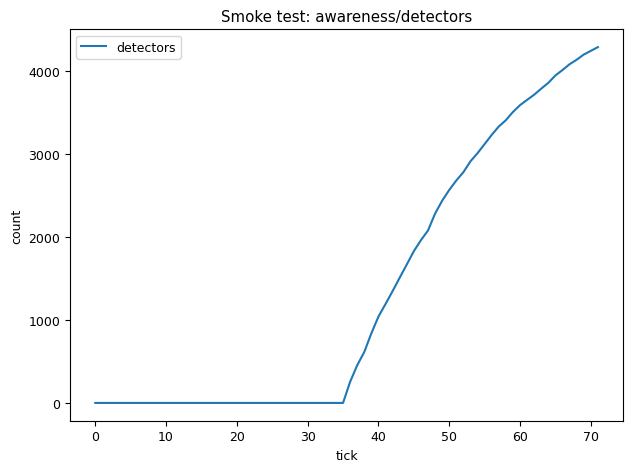

In [31]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"font.size": 9, "pdf.fonttype": 42, "ps.fonttype": 42})

def plot_single_run(timeline: pd.DataFrame, title="Single run"):
    if timeline.empty:
        print("No timeline.csv found or it is empty.")
        return

    tcol = "tick" if "tick" in timeline.columns else (timeline.columns[0] if len(timeline.columns) else None)
    if tcol is None:
        return

    aware_col = "aware" if "aware" in timeline.columns else None
    det_col = "detectors" if "detectors" in timeline.columns else None
    bytes_col = "gossip_bytes_cum" if "gossip_bytes_cum" in timeline.columns else ("gossip_bytes" if "gossip_bytes" in timeline.columns else None)

    if aware_col or det_col:
        plt.figure()
        if aware_col: plt.plot(timeline[tcol], timeline[aware_col], label="aware")
        if det_col: plt.plot(timeline[tcol], timeline[det_col], label="detectors")
        plt.xlabel(tcol); plt.ylabel("count"); plt.title(title + ": awareness/detectors")
        plt.legend(); plt.tight_layout()
        plt.show()

    if bytes_col:
        plt.figure()
        plt.plot(timeline[tcol], timeline[bytes_col])
        plt.xlabel(tcol); plt.ylabel(bytes_col); plt.title(title + f": {bytes_col}")
        plt.tight_layout()
        plt.show()

plot_single_run(timeline, title="Smoke test")

## 5) Main sweep: $p_{gossip} \times a$ (adoption)
Resume-safe sweep runner writes runs into `out_sweeps_nb/main_pgossip_x_adoption/`.

Edit grids and replicates as needed; start small if testing.

In [11]:

from itertools import product
from pathlib import Path
import numpy as np
import pandas as pd
# --- Shorter sweep root to avoid Windows path-length issues ---
SWEEP_ROOT = REPO_ROOT / "out_nb_v4"
SWEEP_ROOT.mkdir(parents=True, exist_ok=True)
OUT_MAIN = SWEEP_ROOT / "main"
OUT_MAIN.mkdir(parents=True, exist_ok=True)
# --- Main sweep grid (p_gossip x adoption) ---
SWEEP_MAIN = dict(
   p_gossip=[0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
   adoption=[0.2, 0.4, 0.6, 0.8, 1.0],
)
REPLICATES = 10
SEED_BASE = 1000
def safe_name(v):
   # Keep folder-safe, short tokens for floats
   if isinstance(v, float):
       return f"{v:g}".replace(".", "p")
   return str(v).replace("/", "_")
def make_outdir_name(cfg, seed):
   """
   Short run names to avoid Windows MAX_PATH issues.
   Encodes only the parameters that vary in this sweep plus essentials.
   """
   sm = cfg.get("server_mode", "m")
   mode = cfg.get("mode", "x")
   pg = safe_name(cfg.get("p_gossip", 0))
   a  = safe_name(cfg.get("adoption", 0))
   f  = safe_name(cfg.get("fork_frac", 0))
   # Example: permanent_fork_sth_proof_pg0p05_a0p2_f0p5_s1000
   return f"{sm}_{mode}_pg{pg}_a{a}_f{f}_s{seed}"
def has_summary(outdir: Path):
   # Ensure directory exists before checking files (more robust on Windows)
   outdir.mkdir(parents=True, exist_ok=True)
   return (outdir / "summary.json").exists()
def run_grid(base: dict, sweep: dict, replicates: int, seed_base: int, outroot: Path):
   outroot = Path(outroot)
   outroot.mkdir(parents=True, exist_ok=True)
   results = []
   grid_keys = list(sweep.keys())
   total = int(np.prod([len(sweep[k]) for k in grid_keys]) * replicates)
   done = 0
   skipped = 0
   for values in product(*[sweep[k] for k in grid_keys]):
       cfg = dict(base)
       cfg.update({k: v for k, v in zip(grid_keys, values)})
       for r in range(replicates):
           seed = seed_base + r
           cfg_run = dict(cfg)
           cfg_run["seed"] = seed
           outdir = outroot / make_outdir_name(cfg_run, seed)
           if not has_summary(outdir):
               # run_sim writes into outdir
               run_sim(cfg_run, outdir=str(outdir))
           else:
               skipped += 1
           summary, _, _ = load_run(outdir)
           dm = derived_metrics(summary, fallback=cfg_run)
           dm["run_dir"] = str(outdir)
           results.append(dm)
           done += 1
           if done % 25 == 0:
               print(f"{done}/{total} done (skipped={skipped})")
   return pd.DataFrame(results)
# --- Run the sweep ---
df_raw_main = run_grid(BASE, SWEEP_MAIN, REPLICATES, SEED_BASE, OUT_MAIN)
# --- Save raw results ---
df_raw_main.to_csv(OUT_MAIN / "all_summaries_raw.csv", index=False)
print("Wrote:", OUT_MAIN / "all_summaries_raw.csv")
df_raw_main.head(), df_raw_main.shape

> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --users 5000 --hours 6 --dt_min 5 --avg_contacts 25 --groups 20000 --avg_group_size 12 --active_hour_mu 14 --active_hour_sigma 4 --active_span_hours 13.75 --msg_rate_1to1 0.1 --msg_rate_group 0.06 --mode sth_proof --p_gossip 0.05 --adoption 0.2 --server_mode permanent_fork --fork_hour 3 --fork_frac 0.5 --fork_duration 2 --sth_period_hours 1 --p_equiv 0.0 --proof_withhold_rate 0.0 --proof_timeout_rate 0.0 --invalid_proof_rate 0.0 --p_drop_crosscut 0.0 --seed 1000 --outdir C:\Users\efasllija\dev\gossip-poc\out_nb_v4\main\permanent_fork_sth_proof_pg0p05_a0p2_f0p5_s1000
Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_v4\main\permanent_fork_sth_proof_pg0p05_a0p2_f0p5_s1000/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_v4\main\permanent_fork_sth_proof_pg0p05_a0p2_f0p5_s1000/timeline.csv.

> C:\Users\efasllija\dev\gossip-poc\.venv\Scripts\python.exe -m sim.run --users 5000 --hours 6 --dt_min 5 --avg_contact

(      server_mode       mode  seed   users  hours  dt_min  fork_hour  \
 0  permanent_fork  sth_proof  1000  5000.0    6.0     5.0        3.0   
 1  permanent_fork  sth_proof  1001  5000.0    6.0     5.0        3.0   
 2  permanent_fork  sth_proof  1002  5000.0    6.0     5.0        3.0   
 3  permanent_fork  sth_proof  1003  5000.0    6.0     5.0        3.0   
 4  permanent_fork  sth_proof  1004  5000.0    6.0     5.0        3.0   
 
    fork_frac  p_gossip  adoption  ...  crosscut_drop_rate_obs  proof_ok  \
 0        0.5      0.05       0.2  ...                     0.0         0   
 1        0.5      0.05       0.2  ...                     0.0         0   
 2        0.5      0.05       0.2  ...                     0.0         0   
 3        0.5      0.05       0.2  ...                     0.0         0   
 4        0.5      0.05       0.2  ...                     0.0         0   
 
    proof_inconsistent  proof_withhold  proof_timeout  proof_total  \
 0                 247          

## 6) Aggregate sweep results

In [12]:

def aggregate(df_raw: pd.DataFrame):
    df = df_raw.copy()
    for c in ["p_gossip","adoption","fork_frac","latency_min","bytes_per_user","bytes_per_msg"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    gcols = ["server_mode","mode","p_gossip","adoption","fork_frac"]
    agg = df.groupby(gcols, dropna=False).agg(
        reps=("run_dir","count"),
        det_rate=("detected","mean"),
        lat_med=("latency_min","median"),
        lat_mean=("latency_min","mean"),
        bpu_mean=("bytes_per_user","mean"),
        bpm_mean=("bytes_per_msg","mean"),
    ).reset_index()
    return agg

df_agg_main = aggregate(df_raw_main)
df_agg_main.to_csv(OUT_MAIN / "all_summaries_agg.csv", index=False)
print("Wrote:", OUT_MAIN / "all_summaries_agg.csv")
df_agg_main.head()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_v4\main\all_summaries_agg.csv


,server_mode,mode,p_gossip,adoption,fork_frac,reps,det_rate,lat_med,lat_mean,bpu_mean,bpm_mean
0,permanent_fork,sth_proof,0.05,0.2,0.5,10,1.0,0.0,1.5,132.69760,8.125808
1,permanent_fork,sth_proof,0.05,0.4,0.5,10,1.0,0.0,0.0,287.75936,17.635345
2,permanent_fork,sth_proof,0.05,0.6,0.5,10,1.0,0.0,0.0,433.44896,26.567827
3,permanent_fork,sth_proof,0.05,0.8,0.5,10,1.0,0.0,0.0,580.16000,35.542086
4,permanent_fork,sth_proof,0.05,1.0,0.5,10,1.0,0.0,0.0,698.16320,42.868159


## 7) Paper plots (USENIX-friendly)
Creates three figures in the main sweep directory:
- detection-rate heatmap
- median-latency heatmap
- overhead vs latency tradeoff scatter

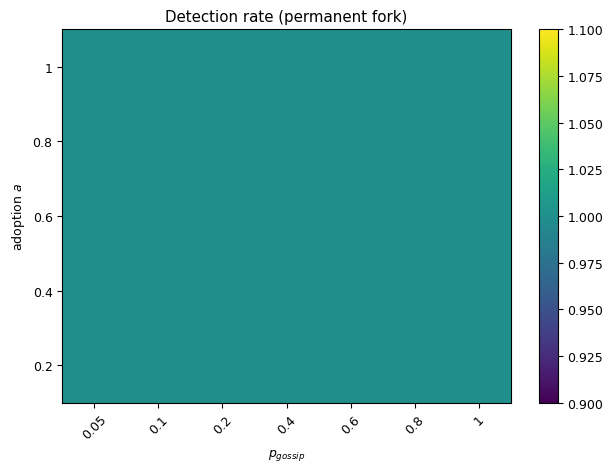

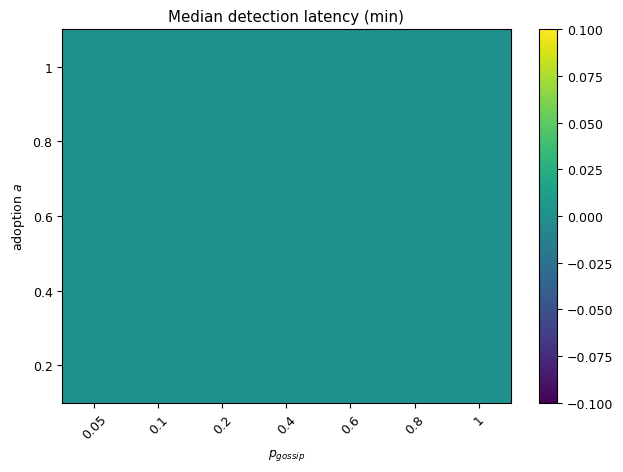

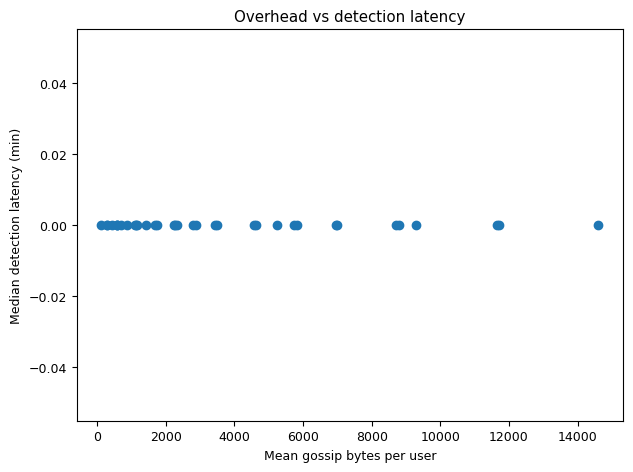

In [13]:

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
mpl.rcParams.update({"font.size": 9, "pdf.fonttype": 42, "ps.fonttype": 42})

hm = df_agg_main.copy()
xs = sorted(hm["p_gossip"].dropna().unique())
ys = sorted(hm["adoption"].dropna().unique())
X = {x:i for i,x in enumerate(xs)}
Y = {y:i for i,y in enumerate(ys)}

# 7a detection-rate heatmap
Z = np.full((len(ys), len(xs)), np.nan)
for _, r in hm.iterrows():
    Z[Y[r["adoption"]], X[r["p_gossip"]]] = r["det_rate"]

plt.figure()
plt.imshow(Z, aspect="auto", origin="lower")
plt.xticks(range(len(xs)), [f"{x:g}" for x in xs], rotation=45)
plt.yticks(range(len(ys)), [f"{y:g}" for y in ys])
plt.xlabel(r"$p_{gossip}$")
plt.ylabel(r"adoption $a$")
plt.title("Detection rate (permanent fork)")
plt.colorbar()
plt.tight_layout()
plt.savefig(OUT_MAIN / "fig_heat_det_rate.pdf")
plt.savefig(OUT_MAIN / "fig_heat_det_rate.png", dpi=300)
plt.show()

# 7b latency heatmap
Z = np.full((len(ys), len(xs)), np.nan)
for _, r in hm.iterrows():
    Z[Y[r["adoption"]], X[r["p_gossip"]]] = r["lat_med"]

plt.figure()
plt.imshow(Z, aspect="auto", origin="lower")
plt.xticks(range(len(xs)), [f"{x:g}" for x in xs], rotation=45)
plt.yticks(range(len(ys)), [f"{y:g}" for y in ys])
plt.xlabel(r"$p_{gossip}$")
plt.ylabel(r"adoption $a$")
plt.title("Median detection latency (min)")
plt.colorbar()
plt.tight_layout()
plt.savefig(OUT_MAIN / "fig_heat_latency.pdf")
plt.savefig(OUT_MAIN / "fig_heat_latency.png", dpi=300)
plt.show()

# 7c tradeoff scatter
df = hm.copy()
df = df[np.isfinite(df["bpu_mean"]) & np.isfinite(df["lat_med"])]

plt.figure()
plt.scatter(df["bpu_mean"], df["lat_med"])
plt.xlabel("Mean gossip bytes per user")
plt.ylabel("Median detection latency (min)")
plt.title("Overhead vs detection latency")
plt.tight_layout()
plt.savefig(OUT_MAIN / "fig_tradeoff.pdf")
plt.savefig(OUT_MAIN / "fig_tradeoff.png", dpi=300)
plt.show()


## 8) Export LaTeX table (top 12 configs)
Exports a tight `booktabs` table for USENIX two-column into the main sweep folder.

In [22]:

from pathlib import Path

tbl = df_agg_main.copy()
tbl = tbl.sort_values(["det_rate","lat_med","bpu_mean"], ascending=[False, True, True])

tbl = tbl[["p_gossip","adoption","reps","det_rate","lat_med","bpu_mean"]].copy()
tbl = tbl.rename(columns={
    "p_gossip": r"$p_{gossip}$",
    "adoption": r"$a$",
    "reps": "reps",
    "det_rate": "Detect",
    "lat_med": "MedLat(min)",
    "bpu_mean": "Bytes/user",
})

latex = tbl.head(12).to_latex(index=False, escape=False, float_format="%.3g")
out_tex = OUT_MAIN / "table_top12.tex"
out_tex.write_text(
    "\\begin{table}[t]\n\\centering\\small\n"
    "\\caption{Top configurations from the $p_{gossip}\\times a$ sweep (permanent fork).}\n"
    "\\label{tab:top_sweep}\n"
    f"{latex}\n\\end{table}\n",
    encoding="utf-8"
)
print("Wrote:", out_tex)
tbl.head(12)


NameError: name 'table' is not defined

## 9) Optional additional scenario sweeps
Uncomment one block at a time.

- rolling equivocation (`server_mode=rolling`, sweep `p_equiv`)
- transient fork duration (`server_mode=transient_fork`, sweep `fork_duration`)
- suppression (`p_drop_crosscut`)
- proof attacks (withhold/timeout/invalid rates)


In [ ]:

# Rolling equivocation sweep (optional)
# BASE_ROLL = dict(BASE); BASE_ROLL["server_mode"] = "rolling"
# SWEEP_ROLL = dict(p_equiv=[0.05, 0.1, 0.2], p_gossip=[0.1, 0.4, 0.8], adoption=[0.4, 0.8, 1.0])
# OUT_ROLL = SWEEP_ROOT / "rolling_pequiv"
# df_raw_roll = run_grid(BASE_ROLL, SWEEP_ROLL, replicates=10, seed_base=2000, outroot=OUT_ROLL)
# df_agg_roll = aggregate(df_raw_roll)
# df_raw_roll.to_csv(OUT_ROLL / "all_summaries_raw.csv", index=False)
# df_agg_roll.to_csv(OUT_ROLL / "all_summaries_agg.csv", index=False)

# Transient fork duration sweep (optional)
# BASE_TR = dict(BASE); BASE_TR["server_mode"] = "transient_fork"
# SWEEP_TR = dict(fork_duration=[1, 2, 4], p_gossip=[0.1, 0.4, 0.8], adoption=[0.4, 0.8, 1.0])
# OUT_TR = SWEEP_ROOT / "transient_fork_duration"
# df_raw_tr = run_grid(BASE_TR, SWEEP_TR, replicates=10, seed_base=3000, outroot=OUT_TR)
# df_agg_tr = aggregate(df_raw_tr)
# df_raw_tr.to_csv(OUT_TR / "all_summaries_raw.csv", index=False)
# df_agg_tr.to_csv(OUT_TR / "all_summaries_agg.csv", index=False)

# Suppression sweep (optional)
# BASE_SUP = dict(BASE)
# SWEEP_SUP = dict(p_drop_crosscut=[0.0, 0.1, 0.3, 0.5], p_gossip=[0.1, 0.4, 0.8], adoption=[0.4, 0.8, 1.0])
# OUT_SUP = SWEEP_ROOT / "suppression_crosscut"
# df_raw_sup = run_grid(BASE_SUP, SWEEP_SUP, replicates=10, seed_base=4000, outroot=OUT_SUP)
# df_agg_sup = aggregate(df_raw_sup)
# df_raw_sup.to_csv(OUT_SUP / "all_summaries_raw.csv", index=False)
# df_agg_sup.to_csv(OUT_SUP / "all_summaries_agg.csv", index=False)

# Proof attacks sweep (optional)
# BASE_PROOF = dict(BASE); BASE_PROOF["mode"] = "sth_proof"
# SWEEP_PROOF = dict(proof_withhold_rate=[0.0, 0.2, 0.5], proof_timeout_rate=[0.0, 0.2], invalid_proof_rate=[0.0, 0.1],
#                    p_gossip=[0.4], adoption=[0.8])
# OUT_PROOF = SWEEP_ROOT / "proof_attacks"
# df_raw_p = run_grid(BASE_PROOF, SWEEP_PROOF, replicates=10, seed_base=5000, outroot=OUT_PROOF)
# df_agg_p = aggregate(df_raw_p)
# df_raw_p.to_csv(OUT_PROOF / "all_summaries_raw.csv", index=False)
# df_agg_p.to_csv(OUT_PROOF / "all_summaries_agg.csv", index=False)

print("Optional sweeps are commented out. Uncomment to run.")
